# 1. Business Understanding

## Introduction
This project analyzes used car market data to identify the key factors that influence vehicle pricing. The main focus is to develop a predictive model that estimates car prices based on vehicle specifications and ownership history.

By applying data analysis and machine learning techniques, the project aims to provide insights that support better pricing decisions in the automobile market.

## Business Understanding
The central question guiding this project is:

**“What are the key determinants of used car prices?”**

Pricing used cars is often challenging due to variations in mileage, age, brand reputation, engine performance, and ownership history. Accurate price estimation is essential for making fair and competitive market decisions.

This project is particularly relevant to the automobile and financial sectors. Its target audience includes:

- **Car dealerships and sellers** – to optimize pricing strategies
- **Buyers** – to assess fair market value
- **Financial institutions and insurers** – to support valuation decisions

The predictive model developed in this project serves as a decision-support tool by:

- Estimating vehicle prices based on specifications
- Identifying the most influential pricing factors
- Supporting data-driven pricing decisions

By combining statistical analysis with machine learning, this project provides valuable insights into used car valuation and market behavior.

### 2. Data Understanding

#### 2.1 Import Libraries

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

import warnings
warnings.filterwarnings('ignore')

#### 2.2 Loading the Data

In [114]:
df = pd.read_csv("Data/car_price_dataset.csv")

### 3. Data Understanding

In [115]:
df.head()

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


In [116]:
df.tail()

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
1995,1996,Hyundai,2023,4.5,Diesel,Manual,155033,2,3,310,61734.35
1996,1997,Toyota,2023,1.4,Petrol,Manual,25044,2,4,271,48467.80
1997,1998,Hyundai,2022,4.1,Diesel,Manual,104372,4,3,191,55714.40
1998,1999,BMW,2020,4.4,Diesel,Automatic,158047,4,1,186,53222.65
1999,2000,Honda,2012,1.7,Electric,Automatic,19706,3,1,165,40687.70


In [117]:
df.columns
df.shape
print("Columns:\n", df.columns)
print("\nShape:", df.shape)

Columns:
 Index(['Car_ID', 'Brand', 'Model_Year', 'Engine_Size', 'Fuel_Type',
       'Transmission', 'Mileage', 'Doors', 'Owner_Count', 'Horsepower',
       'Price'],
      dtype='object')

Shape: (2000, 11)


In [118]:
print("NUMERICAL COLUMNS SUMMARY")
print(df.describe())

print("\nCATEGORICAL COLUMNS SUMMARY")
print(df.describe(include=['object']))

NUMERICAL COLUMNS SUMMARY
            Car_ID   Model_Year  Engine_Size        Mileage        Doors  \
count  2000.000000  2000.000000  2000.000000    2000.000000  2000.000000   
mean   1000.500000  2013.963000     2.967550  100736.956500     2.988000   
std     577.494589     5.508248     1.146926   56002.915221     0.818041   
min       1.000000  2005.000000     1.000000    5036.000000     2.000000   
25%     500.750000  2009.000000     2.000000   52365.500000     2.000000   
50%    1000.500000  2014.000000     2.900000  100590.500000     3.000000   
75%    1500.250000  2019.000000     4.000000  148024.500000     4.000000   
max    2000.000000  2023.000000     5.000000  199904.000000     4.000000   

       Owner_Count  Horsepower         Price  
count  2000.000000  2000.00000   2000.000000  
mean      2.532500   235.70950  46169.507675  
std       1.125423    95.59811   9211.685713  
min       1.000000    70.00000  18911.550000  
25%       2.000000   154.00000  39764.000000  
50%    

In [119]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Percentage (%)": missing_percent
})

print(missing_summary)

              Missing Values  Percentage (%)
Car_ID                     0             0.0
Brand                      0             0.0
Model_Year                 0             0.0
Engine_Size                0             0.0
Fuel_Type                  0             0.0
Transmission               0             0.0
Mileage                    0             0.0
Doors                      0             0.0
Owner_Count                0             0.0
Horsepower                 0             0.0
Price                      0             0.0


In [120]:
print("UNIQUE VALUES PER COLUMN\n")

for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

UNIQUE VALUES PER COLUMN

Car_ID: 2000 unique values
Brand: 6 unique values
Model_Year: 19 unique values
Engine_Size: 41 unique values
Fuel_Type: 4 unique values
Transmission: 2 unique values
Mileage: 1989 unique values
Doors: 3 unique values
Owner_Count: 4 unique values
Horsepower: 329 unique values
Price: 1998 unique values


In [121]:
print("DATA TYPES\n")
print(df.dtypes)

DATA TYPES

Car_ID            int64
Brand            object
Model_Year        int64
Engine_Size     float64
Fuel_Type        object
Transmission     object
Mileage           int64
Doors             int64
Owner_Count       int64
Horsepower        int64
Price           float64
dtype: object


## 4.0  Exploratory Data Analysis

#### 4.1 Target Variable Distribution (Price)

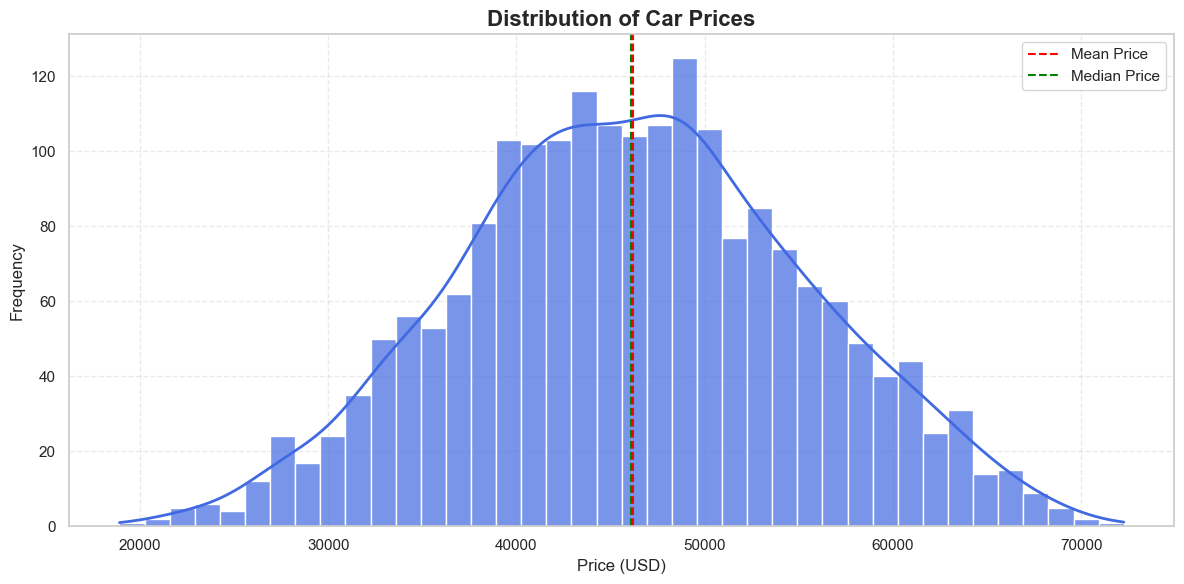

In [122]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df['Price'],
    kde=True,
    bins=40,
    color='royalblue',
    line_kws={'linewidth': 2},
    alpha=0.7
)

plt.title("Distribution of Car Prices", fontsize=16, fontweight='bold')
plt.xlabel("Price (USD)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.axvline(df['Price'].mean(), color='red', linestyle='--', label='Mean Price')
plt.axvline(df['Price'].median(), color='green', linestyle='--', label='Median Price')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

##### Distribution of Car Prices

The price distribution is approximately normal, with most values concentrated around the middle range. The mean and median are very close, showing the data is fairly symmetric with minimal skewness. This indicates a balanced dataset with no extreme outliers dominating the distribution.

#### 4.2 Numerical Feature Distributions

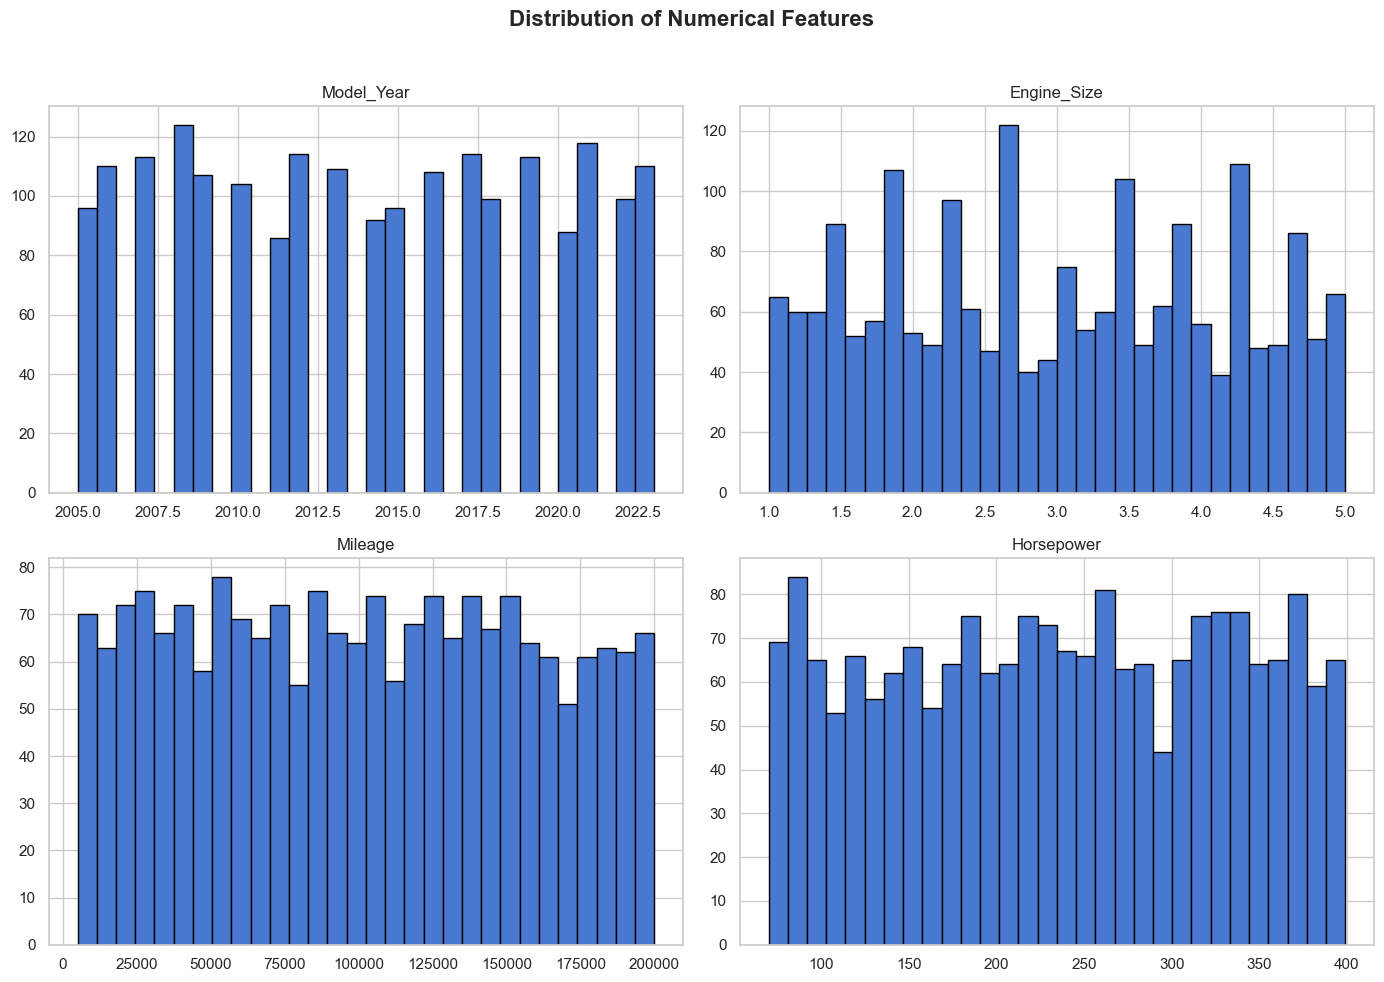

In [123]:
import matplotlib.pyplot as plt

num_cols = ['Model_Year', 'Engine_Size', 'Mileage', 'Horsepower']

df[num_cols].hist(
    figsize=(14, 10),
    bins=30,
    edgecolor='black',
    linewidth=1
)

plt.suptitle("Distribution of Numerical Features", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 4.3 Price vs Numerical Features

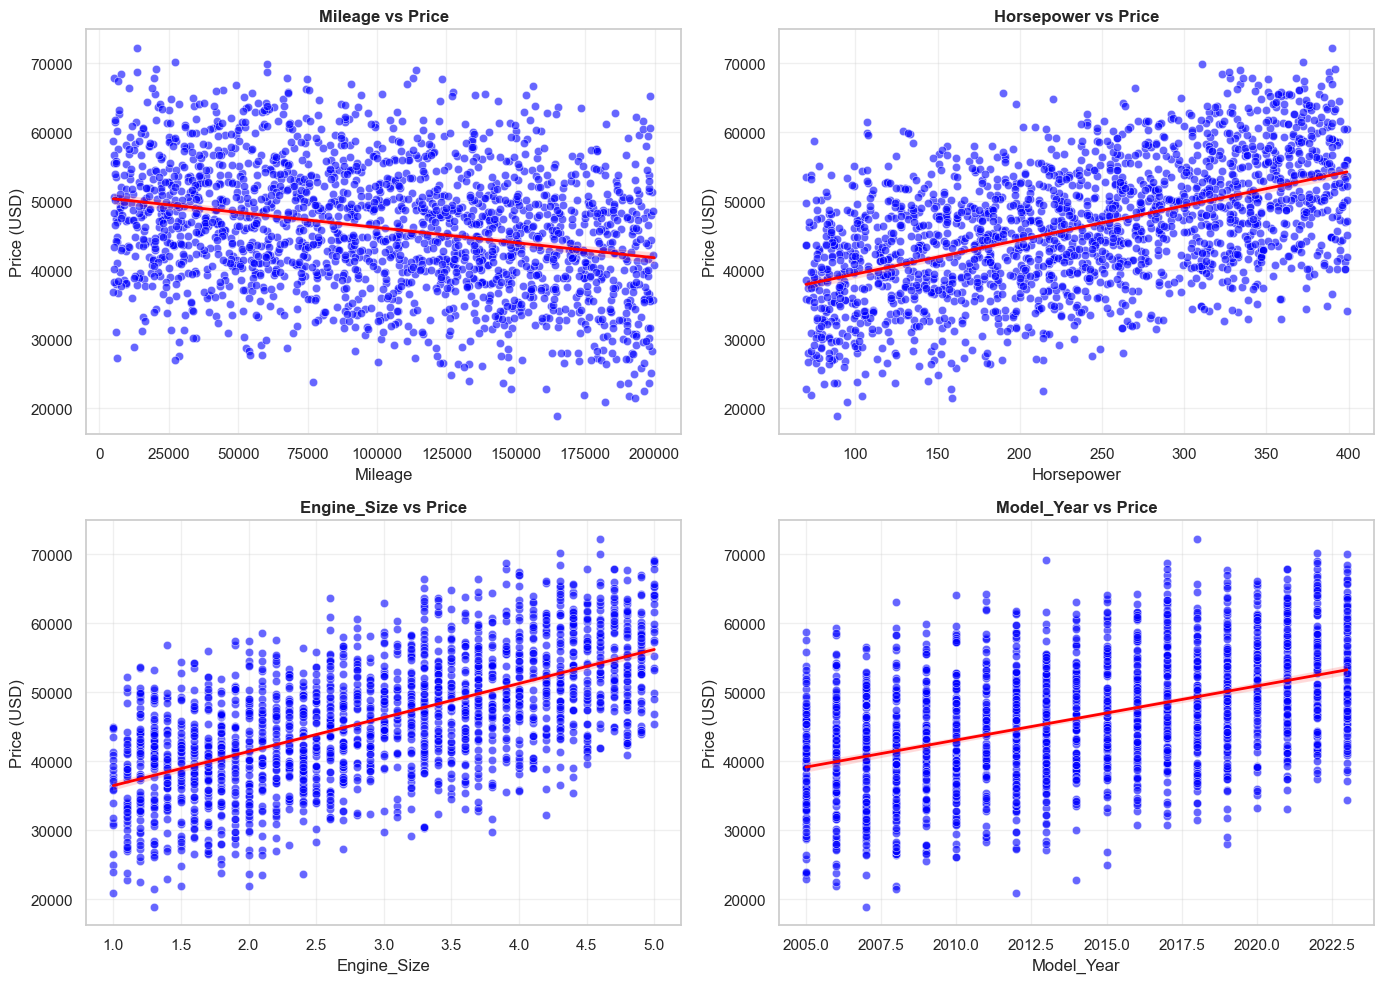

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

features = ['Mileage', 'Horsepower', 'Engine_Size', 'Model_Year']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    
    sns.scatterplot(
        data=df,
        x=col,
        y='Price',
        alpha=0.6,
        color='blue',
        ax=axes[i]
    )
    
    sns.regplot(
        data=df,
        x=col,
        y='Price',
        scatter=False,
        color='red',
        line_kws={"linewidth": 2},
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} vs Price", fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Price (USD)")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

##### Price Relationships with Numerical Features

- **Mileage vs Price:** Shows a negative relationship, where cars with higher mileage tend to have lower prices due to wear and depreciation.  

- **Horsepower vs Price:** Shows a positive relationship, indicating that cars with higher horsepower are generally more expensive.  

- **Engine Size vs Price:** Displays a strong positive correlation, suggesting that larger engine sizes are associated with higher car prices.  

- **Model Year vs Price:** Shows a positive trend, meaning newer vehicles tend to have higher prices because of modern features and lower depreciation.

#### 4.4 Correlation Heatmap

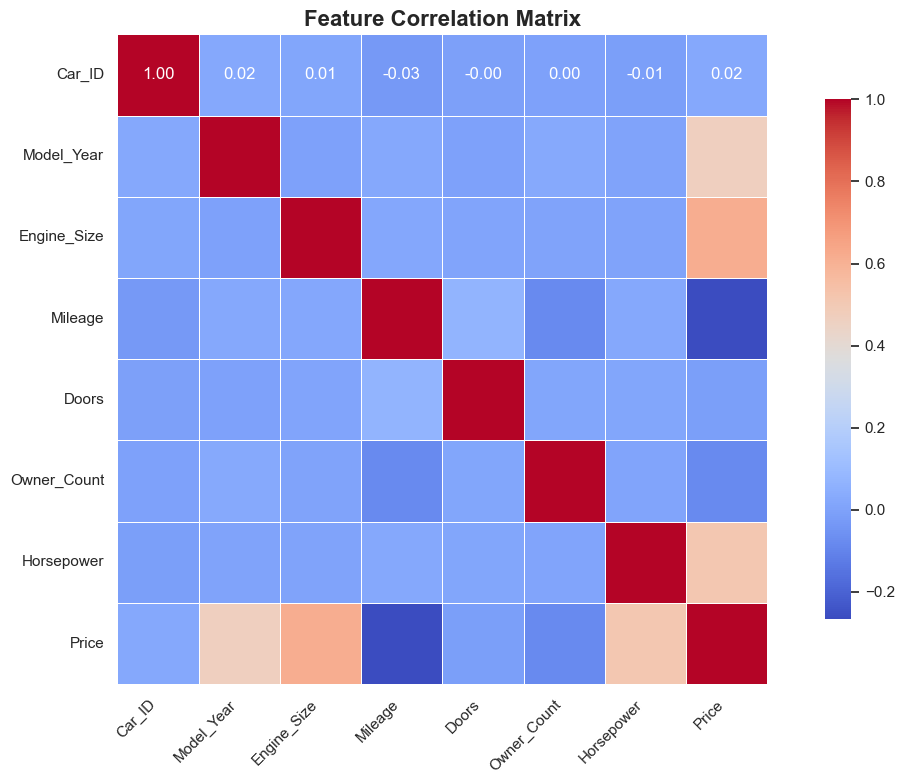

In [125]:
plt.figure(figsize=(12, 8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Matrix", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#### Feature Correlation Matrix

The heatmap shows how each feature relates to the target variable (Price). **Engine_Size, Horsepower, and Model_Year** have a positive correlation with price, meaning they increase price as they increase. **Mileage** shows a negative correlation, meaning higher mileage reduces car value. Most other features have weak or near-zero correlation with price.

In [126]:
import pandas as pd

df_fe = df.copy()

# -----------------------------
# Feature Engineering
# -----------------------------
df_fe['Car_Age'] = 2026 - df_fe['Model_Year']
df_fe['Mileage_per_Year'] = df_fe['Mileage'] / (df_fe['Car_Age'] + 1)
df_fe['Power_to_Engine'] = df_fe['Horsepower'] / df_fe['Engine_Size']

df_fe['Is_Automatic'] = (df_fe['Transmission'] == 'Automatic').astype(int)

# Drop unused columns
df_fe.drop(['Model_Year', 'Car_ID'], axis=1, inplace=True, errors='ignore')

In [127]:
from sklearn.model_selection import train_test_split

X = df_fe.drop('Price', axis=1)
y = df_fe['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 5.0 Modelling 

#### 5.1 Linear Regression (BaseLine Model)

In [128]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# -----------------------------
# Identify column types
# -----------------------------
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

# -----------------------------
# Preprocessing
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

# -----------------------------
# Full Pipeline
# -----------------------------
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [129]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['Brand', 'Fuel_Type', 'Transmission'], dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['Engine_Size', 'Mileage', 'Doors', 'Owner_Count', 'Horsepower',
       'Car_Age', 'Mileage_per_Year', 'Power_to_Engine'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

In [130]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))

MAE : 1441.4452491840302
RMSE: 1662.1379583948187
R2  : 0.9665204696248086


#### 5.2 Random Forest Regressor

In [131]:
df_fe = df.copy()

df_fe['Car_Age'] = 2026 - df_fe['Model_Year']
df_fe['Mileage_per_Year'] = df_fe['Mileage'] / (df_fe['Car_Age'] + 1)
df_fe['Power_to_Engine'] = df_fe['Horsepower'] / df_fe['Engine_Size']

df_fe.drop(['Model_Year', 'Car_ID'], axis=1, inplace=True, errors='ignore')

In [132]:
X = df_fe.drop('Price', axis=1)
y = df_fe['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [133]:
cat_cols = X_train.select_dtypes(include=['object']).columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

In [134]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=400,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

In [135]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Brand', 'Fuel_Type', 'Transmission'], dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['Engine_Size', 'Mileage', 'Doors', 'Owner_Count', 'Horsepower',
       'Car_Age', 'Mileage_per_Year', 'Power_to_Engine'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(max_depth=15, min_samples_leaf=2,
                                       min_samples_split=5, n_estimators=400,
                                       n_jobs=-1, random_state=42))])

In [136]:
y_pred = rf_model.predict(X_test)

In [137]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Results (Fixed)")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

Random Forest Results (Fixed)
MAE : 2168.464818397279
RMSE: 2681.9717726130316
R2  : 0.912832693277385


### 5.3 XGBOOST REGRESSION


In [138]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

In [139]:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Brand', 'Fuel_Type', 'Transmission'], dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['Engine_Size', 'Mileage', 'Doors', 'Owner_Count', 'Horsepower',
       'Car_Age', 'Mileage_per_Year', 'Power_to_Engine'],
      dtype='object'))])),
                ('model',
                 XGBRegressor(bas...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, random_state=42, ...))])

In [140]:
y_pred_xgb = xgb_model.predict(X_test)

In [141]:
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

XGBoost Results
MAE : 1750.6866123046875
RMSE: 2128.5582283083554
R2  : 0.945094444173136


## 6.0 Model comparison visualization

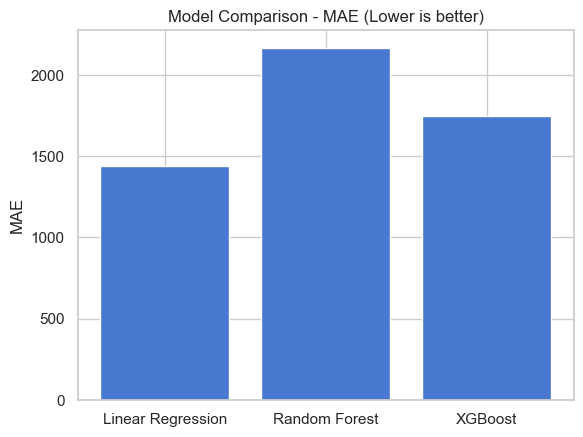

In [142]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Linear Regression', 'Random Forest', 'XGBoost']

mae = [1441, 2168, 1751]
rmse = [1662, 2682, 2129]
r2 = [0.966, 0.913, 0.945]
plt.figure()
plt.bar(models, mae)
plt.title("Model Comparison - MAE (Lower is better)")
plt.ylabel("MAE")
plt.show()

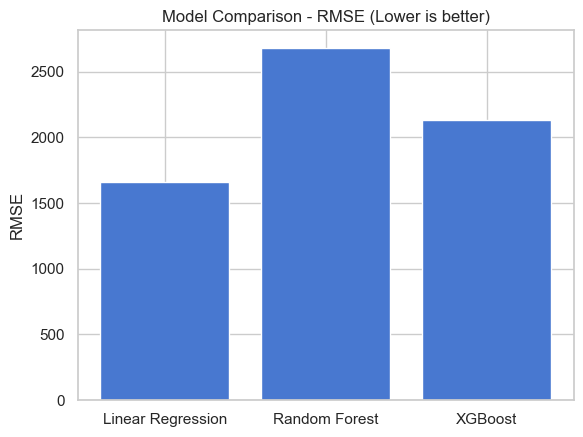

In [143]:
plt.figure()
plt.bar(models, rmse)
plt.title("Model Comparison - RMSE (Lower is better)")
plt.ylabel("RMSE")
plt.show()

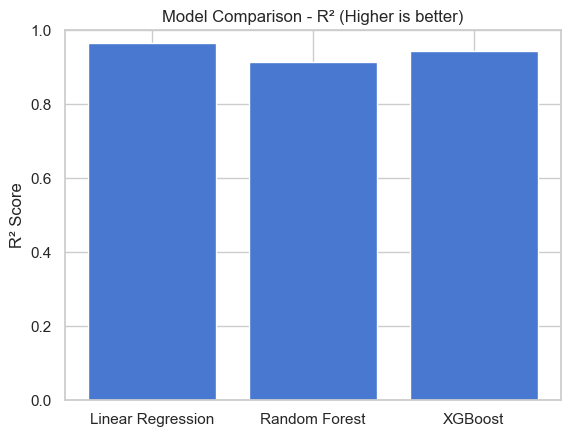

In [144]:
plt.figure()
plt.bar(models, r2)
plt.title("Model Comparison - R² (Higher is better)")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.show()

### 6.1 Feature Importance (XGBoost)

In [145]:
import pandas as pd

xgb_model.fit(X_train, y_train)

# Get feature names after preprocessing
feature_names = xgb_model.named_steps['preprocessor'].get_feature_names_out()

importances = xgb_model.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_imp.head(10)

,Feature,Importance
12,num__Engine_Size,0.311008
17,num__Car_Age,0.246754
16,num__Horsepower,0.181954
19,num__Power_to_Engine,0.086832
13,num__Mileage,0.059795
15,num__Owner_Count,0.029782
18,num__Mileage_per_Year,0.029185
3,cat__Brand_Hyundai,0.006906
4,cat__Brand_Tesla,0.005802
2,cat__Brand_Honda,0.005279


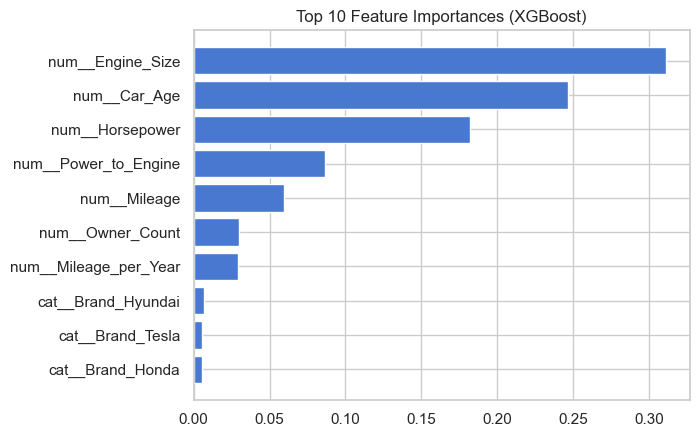

In [146]:
top_features = feat_imp.head(10)

plt.figure()
plt.barh(top_features['Feature'], top_features['Importance'])
plt.title("Top 10 Feature Importances (XGBoost)")
plt.gca().invert_yaxis()
plt.show()

### Why Linear Regression Was Chosen as the Final Model

Linear Regression was selected as the final model because it delivered the best overall performance on this dataset compared to more complex models like Random Forest and XGBoost. The dataset is largely linear in structure, and the engineered features effectively capture most of the relationship between predictors and the target (Price).

The model achieved strong evaluation metrics:
- **MAE:** 1441.45  
- **RMSE:** 1662.14  
- **R²:** 0.9665  

These results show that the model explains approximately **96.65% of the variance in car prices**, with relatively low prediction error. This indicates that the underlying patterns in the data are well represented by a linear relationship, making Linear Regression not only interpretable but also the most accurate model for this problem.

## 7 Save best model

In [148]:
import joblib

joblib.dump(model, "best_model.pkl")

['best_model.pkl']